#Download the Dataset via Drive

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Step 1: Load and Inspect the Raw Data

In [24]:
import pandas as pd
import numpy as np

In [25]:
#Load and handle '?' values
df = pd.read_csv('/content/drive/MyDrive/AI RESEARCH/SPE NAICE/household_power_consumption.txt',
                 sep=';',
                 na_values=['?'],
                 low_memory=False
                 )
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


#Step 2: Create Datetime Index

In [26]:
df['dt'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df.set_index('dt', inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [27]:
print(df.index)

DatetimeIndex(['2006-12-16 17:24:00', '2006-12-16 17:25:00',
               '2006-12-16 17:26:00', '2006-12-16 17:27:00',
               '2006-12-16 17:28:00', '2006-12-16 17:29:00',
               '2006-12-16 17:30:00', '2006-12-16 17:31:00',
               '2006-12-16 17:32:00', '2006-12-16 17:33:00',
               ...
               '2010-11-26 20:53:00', '2010-11-26 20:54:00',
               '2010-11-26 20:55:00', '2010-11-26 20:56:00',
               '2010-11-26 20:57:00', '2010-11-26 20:58:00',
               '2010-11-26 20:59:00', '2010-11-26 21:00:00',
               '2010-11-26 21:01:00', '2010-11-26 21:02:00'],
              dtype='datetime64[ns]', name='dt', length=2075259, freq=None)


#Step 3: Handle Missing Values

In [28]:
print(df.shape)
print(df.isnull().sum())

(2075259, 7)
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [29]:
#Fill missing values using forward fill
df.ffill(inplace=True)

#Confirm no more missing values
print(df.isnull().sum())

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


#Step 4: Resample from Minute → Hourly

Since the data is recorded every minute, we need to aggregate it to hourly intervals for our prediction task.

In [30]:
#Resample to hourly by taking the mean
df_hourly = df.resample('H').mean()

print(df_hourly.shape)
print(df_hourly.head())

(34589, 7)
                     Global_active_power  Global_reactive_power     Voltage  \
dt                                                                            
2006-12-16 17:00:00             4.222889               0.229000  234.643889   
2006-12-16 18:00:00             3.632200               0.080033  234.580167   
2006-12-16 19:00:00             3.400233               0.085233  233.232500   
2006-12-16 20:00:00             3.268567               0.075100  234.071500   
2006-12-16 21:00:00             3.056467               0.076667  237.158667   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
dt                                                                      
2006-12-16 17:00:00         18.100000             0.0        0.527778   
2006-12-16 18:00:00         15.600000             0.0        6.716667   
2006-12-16 19:00:00         14.503333             0.0        1.433333   
2006-12-16 20:00:00         13.916667             0.0        0.000000 

/tmp/ipykernel_283/1960342433.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean()


#Step 5: Engineer Time-Based Features
Now we add temporal features that help the model understand patterns like time of day, day of week, weekends etc.

In [31]:
df_hourly['hour']        = df_hourly.index.hour
df_hourly['day_of_week'] = df_hourly.index.dayofweek
df_hourly['month']       = df_hourly.index.month
df_hourly['is_weekend']  = df_hourly['day_of_week'].isin([5, 6]).astype(int)
df_hourly['is_daytime']  = df_hourly['hour'].between(6, 18).astype(int)

print(df_hourly[['hour', 'day_of_week', 'month', 'is_weekend', 'is_daytime']].head(10))

                     hour  day_of_week  month  is_weekend  is_daytime
dt                                                                   
2006-12-16 17:00:00    17            5     12           1           1
2006-12-16 18:00:00    18            5     12           1           1
2006-12-16 19:00:00    19            5     12           1           0
2006-12-16 20:00:00    20            5     12           1           0
2006-12-16 21:00:00    21            5     12           1           0
2006-12-16 22:00:00    22            5     12           1           0
2006-12-16 23:00:00    23            5     12           1           0
2006-12-17 00:00:00     0            6     12           1           0
2006-12-17 01:00:00     1            6     12           1           0
2006-12-17 02:00:00     2            6     12           1           0


#Step 6: Add Nigeria-Specific Power Source Features
We now simulate the 3 power sources — Grid, Solar and Generator — based on realistic Nigerian power supply patterns.

In [32]:
# Solar: available between 7am and 6pm
df_hourly['solar_available'] = df_hourly['hour'].between(7, 18).astype(int)

# Grid: simulate NEPA availability (~8 hrs/day, typically morning and evening)
np.random.seed(42)
grid_hours = [6, 7, 8, 9, 18, 19, 20, 21]
df_hourly['grid_available'] = df_hourly['hour'].isin(grid_hours).astype(int)

# Generator: kicks in when both grid and solar are unavailable
df_hourly['gen_active'] = (
    (df_hourly['grid_available'] == 0) &
    (df_hourly['solar_available'] == 0)
).astype(int)

print(df_hourly[['hour', 'grid_available', 'solar_available', 'gen_active']].head(24))

                     hour  grid_available  solar_available  gen_active
dt                                                                    
2006-12-16 17:00:00    17               0                1           0
2006-12-16 18:00:00    18               1                1           0
2006-12-16 19:00:00    19               1                0           0
2006-12-16 20:00:00    20               1                0           0
2006-12-16 21:00:00    21               1                0           0
2006-12-16 22:00:00    22               0                0           1
2006-12-16 23:00:00    23               0                0           1
2006-12-17 00:00:00     0               0                0           1
2006-12-17 01:00:00     1               0                0           1
2006-12-17 02:00:00     2               0                0           1
2006-12-17 03:00:00     3               0                0           1
2006-12-17 04:00:00     4               0                0           1
2006-1

#Step 7: Add Lag Features
Lag features tell the model what consumption looked like in the past — which is critical for time series forecasting.

In [33]:
df_hourly['lag_1h']   = df_hourly['Global_active_power'].shift(1)
df_hourly['lag_24h']  = df_hourly['Global_active_power'].shift(24)
df_hourly['lag_168h'] = df_hourly['Global_active_power'].shift(168)

print(df_hourly[['Global_active_power', 'lag_1h', 'lag_24h', 'lag_168h']].head(10))
print("\nMissing values after lag:\n", df_hourly[['lag_1h', 'lag_24h', 'lag_168h']].isnull().sum())

                     Global_active_power    lag_1h  lag_24h  lag_168h
dt                                                                   
2006-12-16 17:00:00             4.222889       NaN      NaN       NaN
2006-12-16 18:00:00             3.632200  4.222889      NaN       NaN
2006-12-16 19:00:00             3.400233  3.632200      NaN       NaN
2006-12-16 20:00:00             3.268567  3.400233      NaN       NaN
2006-12-16 21:00:00             3.056467  3.268567      NaN       NaN
2006-12-16 22:00:00             2.200133  3.056467      NaN       NaN
2006-12-16 23:00:00             2.061600  2.200133      NaN       NaN
2006-12-17 00:00:00             1.882467  2.061600      NaN       NaN
2006-12-17 01:00:00             3.349400  1.882467      NaN       NaN
2006-12-17 02:00:00             1.587267  3.349400      NaN       NaN

Missing values after lag:
 lag_1h        1
lag_24h      24
lag_168h    168
dtype: int64


#Step 8: Add Rolling Statistics
Rolling features give the model a moving average and volatility of past consumption.

In [34]:
df_hourly['rolling_mean_24h'] = df_hourly['Global_active_power'].rolling(24).mean()
df_hourly['rolling_std_24h']  = df_hourly['Global_active_power'].rolling(24).std()

print(df_hourly[['Global_active_power', 'rolling_mean_24h', 'rolling_std_24h']].head(30))
print("\nMissing values:\n", df_hourly[['rolling_mean_24h', 'rolling_std_24h']].isnull().sum())

                     Global_active_power  rolling_mean_24h  rolling_std_24h
dt                                                                         
2006-12-16 17:00:00             4.222889               NaN              NaN
2006-12-16 18:00:00             3.632200               NaN              NaN
2006-12-16 19:00:00             3.400233               NaN              NaN
2006-12-16 20:00:00             3.268567               NaN              NaN
2006-12-16 21:00:00             3.056467               NaN              NaN
2006-12-16 22:00:00             2.200133               NaN              NaN
2006-12-16 23:00:00             2.061600               NaN              NaN
2006-12-17 00:00:00             1.882467               NaN              NaN
2006-12-17 01:00:00             3.349400               NaN              NaN
2006-12-17 02:00:00             1.587267               NaN              NaN
2006-12-17 03:00:00             1.662200               NaN              NaN
2006-12-17 0

#Step 9: Create Target Variable & Drop NaN Rows
We define what we want to predict (next hour's consumption) and drop all rows with NaN values created by lags and rolling windows.

In [35]:
# Target: next hour's consumption
df_hourly['target'] = df_hourly['Global_active_power'].shift(-1)

# Drop all rows with NaN (from lags, rolling, and target)
df_hourly.dropna(inplace=True)

print(df_hourly.shape)
print(df_hourly[['Global_active_power', 'lag_1h', 'lag_24h', 'lag_168h',
                  'rolling_mean_24h', 'rolling_std_24h', 'target']].head())
print("\nMissing values:\n", df_hourly.isnull().sum())

(34420, 21)
                     Global_active_power    lag_1h   lag_24h  lag_168h  \
dt                                                                       
2006-12-23 17:00:00             5.452533  4.349100  1.496800  4.222889   
2006-12-23 18:00:00             3.879400  5.452533  2.686967  3.632200   
2006-12-23 19:00:00             4.117833  3.879400  3.938167  3.400233   
2006-12-23 20:00:00             4.181400  4.117833  3.536067  3.268567   
2006-12-23 21:00:00             3.288433  4.181400  4.548667  3.056467   

                     rolling_mean_24h  rolling_std_24h    target  
dt                                                                
2006-12-23 17:00:00          3.099713         1.066674  3.879400  
2006-12-23 18:00:00          3.149397         1.074356  4.117833  
2006-12-23 19:00:00          3.156883         1.080699  4.181400  
2006-12-23 20:00:00          3.183772         1.098426  3.288433  
2006-12-23 21:00:00          3.131263         1.059784  4.327933  


In [37]:
df_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,month,...,is_daytime,solar_available,grid_available,gen_active,lag_1h,lag_24h,lag_168h,rolling_mean_24h,rolling_std_24h,target
dt,,,,,,,,,,,,,,,,,,,,,
2006-12-23 17:00:00,5.452533,0.215967,233.644167,23.360000,16.183333,0.666667,16.750000,17,5,12,...,1,1,0,0,4.349100,1.496800,4.222889,3.099713,1.066674,3.879400
2006-12-23 18:00:00,3.879400,0.099767,238.000500,16.363333,0.000000,0.016667,17.350000,18,5,12,...,1,1,1,0,5.452533,2.686967,3.632200,3.149397,1.074356,4.117833
2006-12-23 19:00:00,4.117833,0.205333,238.729333,17.300000,0.000000,0.600000,17.466667,19,5,12,...,0,0,1,0,3.879400,3.938167,3.400233,3.156883,1.080699,4.181400
2006-12-23 20:00:00,4.181400,0.124767,238.518833,17.596667,0.000000,0.350000,17.416667,20,5,12,...,0,0,1,0,4.117833,3.536067,3.268567,3.183772,1.098426,3.288433
2006-12-23 21:00:00,3.288433,0.235767,238.594667,13.893333,0.000000,0.216667,5.666667,21,5,12,...,0,0,1,0,4.181400,4.548667,3.056467,3.131263,1.059784,4.327933


#Step 10: Train/Test Split
We split the data temporally — never randomly for time series.

In [38]:
# Define features and target
features = [col for col in df_hourly.columns if col != 'target']
X = df_hourly[features]
y = df_hourly['target']

# Temporal split: 80% train, 10% val, 10% test
n = len(df_hourly)
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val,   y_val   = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test,  y_test  = X.iloc[val_end:], y.iloc[val_end:]

print(f"Train size : {X_train.shape}")
print(f"Val size   : {X_val.shape}")
print(f"Test size  : {X_test.shape}")
print(f"\nTrain period: {X_train.index[0]} → {X_train.index[-1]}")
print(f"Val period  : {X_val.index[0]} → {X_val.index[-1]}")
print(f"Test period : {X_test.index[0]} → {X_test.index[-1]}")

Train size : (27536, 20)
Val size   : (3442, 20)
Test size  : (3442, 20)

Train period: 2006-12-23 17:00:00 → 2010-02-13 00:00:00
Val period  : 2010-02-13 01:00:00 → 2010-07-06 10:00:00
Test period : 2010-07-06 11:00:00 → 2010-11-26 20:00:00


#Step 11: Train XGBoost Model
Now we train our first model on the training set and evaluate it on the validation set.

In [39]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Train model
model = XGBRegressor(n_estimators=500, learning_rate=0.05,
                     max_depth=6, random_state=42, n_jobs=-1)
model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          verbose=100)

# Validate
y_pred_val = model.predict(X_val)

MAE  = mean_absolute_error(y_val, y_pred_val)
RMSE = np.sqrt(mean_squared_error(y_val, y_pred_val))
MAPE = np.mean(np.abs((y_val - y_pred_val) / y_val)) * 100

print(f"\nValidation Results:")
print(f"MAE  : {MAE:.4f}")
print(f"RMSE : {RMSE:.4f}")
print(f"MAPE : {MAPE:.4f}%")

[0]	validation_0-rmse:0.71474
[100]	validation_0-rmse:0.46689
[200]	validation_0-rmse:0.46594
[300]	validation_0-rmse:0.46586
[400]	validation_0-rmse:0.46757
[499]	validation_0-rmse:0.46880

Validation Results:
MAE  : 0.3227
RMSE : 0.4688
MAPE : 38.6421%


#Step 12: Evaluate on Test Set
Now we evaluate on the unseen test set — the true measure of model performance.

In [40]:
# Test set evaluation
y_pred_test = model.predict(X_test)

MAE  = mean_absolute_error(y_test, y_pred_test)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred_test))
MAPE = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

print(f"Test Results:")
print(f"MAE  : {MAE:.4f}")
print(f"RMSE : {RMSE:.4f}")
print(f"MAPE : {MAPE:.4f}%")

Test Results:
MAE  : 0.3105
RMSE : 0.4471
MAPE : 47.6177%


#Step 13: Plot Actual vs Predicted
Let's visually inspect how well the model is predicting.

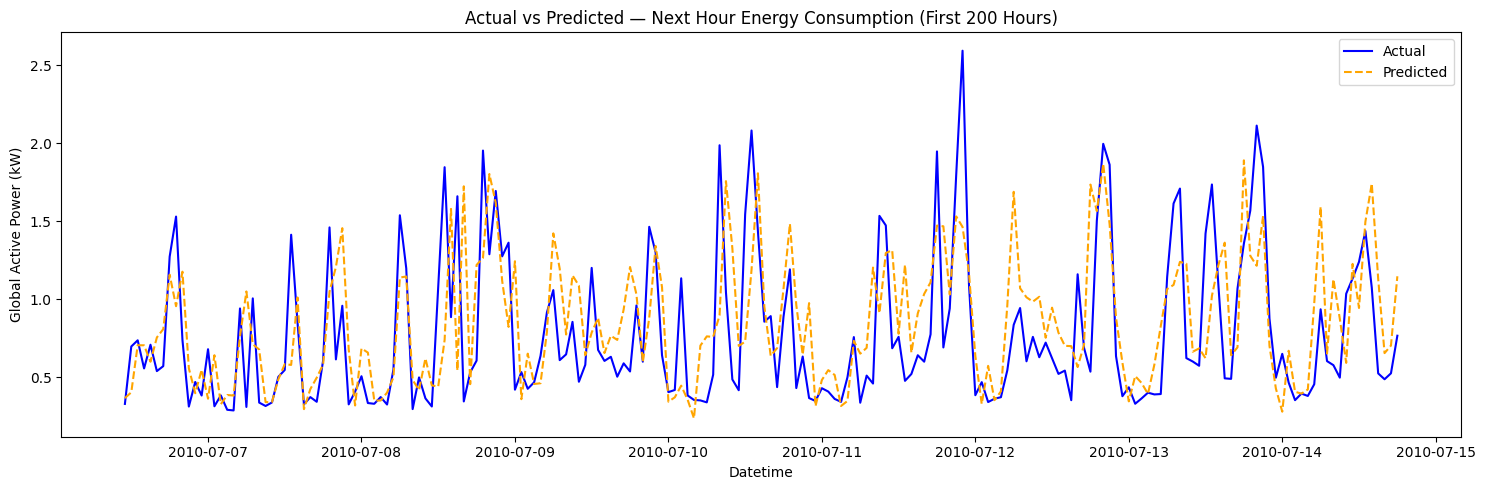

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(y_test.index[:200], y_test.values[:200],
         label='Actual', color='blue', linewidth=1.5)
plt.plot(y_test.index[:200], y_pred_test[:200],
         label='Predicted', color='orange', linewidth=1.5, linestyle='--')
plt.title('Actual vs Predicted — Next Hour Energy Consumption (First 200 Hours)')
plt.xlabel('Datetime')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.tight_layout()
plt.show()

#Step 14: Feature Importance
Let's see which features the model relied on most to make predictions.

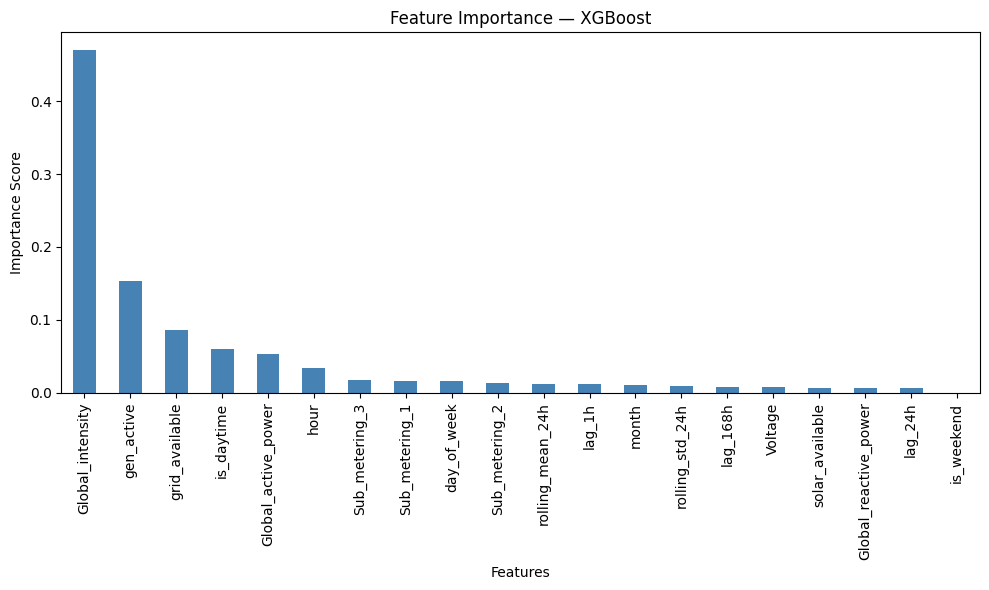

Global_intensity         0.470742
gen_active               0.152718
grid_available           0.086571
is_daytime               0.059432
Global_active_power      0.052773
hour                     0.033460
Sub_metering_3           0.018289
Sub_metering_1           0.016090
day_of_week              0.016063
Sub_metering_2           0.013171
rolling_mean_24h         0.012074
lag_1h                   0.011868
month                    0.011005
rolling_std_24h          0.009425
lag_168h                 0.007646
Voltage                  0.007440
solar_available          0.007170
Global_reactive_power    0.007097
lag_24h                  0.006966
is_weekend               0.000000
dtype: float32


In [42]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — XGBoost')
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

print(importance)

#Step 15: Save the Model
Let's save the trained model so it can be reused without retraining.

In [43]:
import joblib

joblib.dump(model, 'energy_forecast_model.pkl')

print("Model saved successfully as 'energy_forecast_model.pkl'")
print(f"File size: {__import__('os').path.getsize('energy_forecast_model.pkl') / 1024:.1f} KB")

Model saved successfully as 'energy_forecast_model.pkl'
File size: 2175.1 KB


#Step 16: Make a Single Prediction
Let's test the model by feeding it one row of data and predicting the next hour's consumption — simulating real-world usage.

In [44]:
# Take one sample from test set
sample = X_test.iloc[[0]]

# Predict
prediction = model.predict(sample)[0]
actual = y_test.iloc[0]

print(f"Sample DateTime  : {X_test.index[0]}")
print(f"Predicted (next hour) : {prediction:.4f} kW")
print(f"Actual    (next hour) : {actual:.4f} kW")
print(f"Error                 : {abs(prediction - actual):.4f} kW")

# Show which power source is active
print(f"\nPower Source Status:")
print(f"Grid Available  : {'Yes' if sample['grid_available'].values[0] else 'No'}")
print(f"Solar Available : {'Yes' if sample['solar_available'].values[0] else 'No'}")
print(f"Generator Active: {'Yes' if sample['gen_active'].values[0] else 'No'}")

Sample DateTime  : 2010-07-06 11:00:00
Predicted (next hour) : 0.3664 kW
Actual    (next hour) : 0.3290 kW
Error                 : 0.0373 kW

Power Source Status:
Grid Available  : No
Solar Available : Yes
Generator Active: No
